--- GELİŞMİŞ MEDİKAL MODEL SONUÇLARI ---

[Logistic Regression]
Accuracy : %98.25 | AUC: 0.997
Doğru Sağlıklı Teşhisi (TN) : 70
Doğru Kanser Teşhisi (TP)   : 42
Yanlış Alarm (FP) : 1
Kanseri Gözden Kaçırdı (FN) : 1
--------------------------------------------------
[SVM (Support Vector)]
Accuracy : %96.49 | AUC: 0.997
Doğru Sağlıklı Teşhisi (TN) : 69
Doğru Kanser Teşhisi (TP)   : 41
Yanlış Alarm (FP) : 2
Kanseri Gözden Kaçırdı (FN) : 2
--------------------------------------------------
[Random Forest]
Accuracy : %96.49 | AUC: 0.998
Doğru Sağlıklı Teşhisi (TN) : 70
Doğru Kanser Teşhisi (TP)   : 40
Yanlış Alarm (FP) : 1
Kanseri Gözden Kaçırdı (FN) : 3
--------------------------------------------------


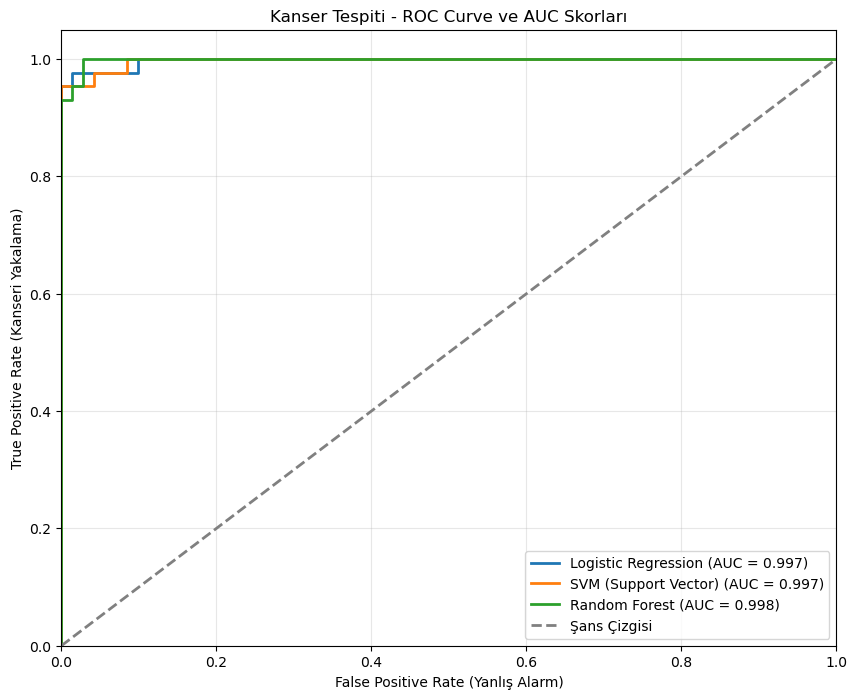

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score , roc_curve, auc

# 1. VERİYİ OKUMA VE TEMİZLEME
df = pd.read_csv('data.csv')

# Gereksiz 'id' ve sonundaki boş 'Unnamed: 32' kolonlarını siliyoruz
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# 2. HEDEF DEĞİŞKENİ (TARGET) HAZIRLAMA
# 'M' (Malignant/Kötü Huylu) -> 1
# 'B' (Benign/İyi Huylu)     -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Bağımsız (X) ve Bağımlı (y) değişkenleri ayırma
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Train/Test Split (%20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing (Scaling)
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# 3. MODELLERİ KURMA (SINIF DENGESİZLİĞİNİ ÇÖZEREK)
# Tüm modellere class_weight='balanced' ekledik!
# SVM'de ROC çizebilmek için probability=True parametresini açmamız şarttır.
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "SVM (Support Vector)": SVC(probability=True, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42)
}


print("--- GELİŞMİŞ MEDİKAL MODEL SONUÇLARI ---\n")

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Eğit ve Tahmin Yap
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Olasılıkları hesapla (ROC Curve için gerekli)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrikleri hesapla
    acc = accuracy_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Ekrana Yazdır
    print(f"[{name}]")
    print(f"Accuracy : %{acc*100:.2f} | AUC: {roc_auc:.3f}")
    print(f"Doğru Sağlıklı Teşhisi (TN) : {tn}")
    print(f"Doğru Kanser Teşhisi (TP)   : {tp}")
    print(f"Yanlış Alarm (FP) : {fp}")
    print(f"Kanseri Gözden Kaçırdı (FN) : {fn}")
    print("-" * 50)
    
    # Grafiğe Ekle
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# 4. ROC CURVE GÖRSELLEŞTİRME
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Şans Çizgisi')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Alarm)')
plt.ylabel('True Positive Rate (Kanseri Yakalama)')
plt.title('Kanser Tespiti - ROC Curve ve AUC Skorları')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Accuracy Paradox Analizi
Eğer veri setinde hasta olmayan kişi sayısı çok fazlaysa accuracy neden yanıltıcı olabilir?

"Accuracy Paradox" (Doğruluk Paradoksu), veri setindeki sınıflar arasında devasa bir uçurum (imbalance) olduğunda ortaya çıkan ve makine öğrenmesi mühendislerini en çok tuzağa düşüren istatistiksel bir yanılsamadır. Bir toplumda sağlıklı insanların sayısının, kanserli hastaların sayısından çok daha fazla olduğunu düşünelim; örneğin hastaneye gelen bin kişinin %99'u sağlıklı ve sadece %1'i hasta olsun. Eğer acemi bir mühendisin kurduğu makine öğrenmesi modeli, hastaların tahlil sonuçlarına hiç bakmadan kapıdan giren herkese körü körüne 'Sen sağlıklısın (0)' diyecek şekilde programlanırsa, sistemin genel doğruluk oranı (Accuracy) matematiksel olarak %99 çıkacaktır! Yöneticiler ekrandaki %99 Accuracy oranını gördüğünde modelin yapay zeka harikası olduğunu sanıp bunu hemen hastanelere dağıtabilirler. Ancak bu aptal model, gerçekte kanser olan o %1'lik kesimi tamamen gözden kaçırmıştır; yani asıl bulmamız gereken tehlikeyi bulma konusundaki gerçek başarısı aslında %0'dır. Sınıf dengesizliği olan durumlarda Accuracy metrisi, sadece çoğunluk sınıfının (sağlıklı olanların) kalabalık sayısından beslenerek kendi skorunu yapay bir şekilde şişirir ve azınlık sınıfının (kanserli hastaların) yaşadığı dramatik başarısızlığı ustaca maskeler. Bu nedenle tıp, dolandırıcılık tespiti (fraud detection) veya kredi temerrütleri gibi "samanlıkta iğne aramaya" çalıştığımız projelerde Accuracy metriğine asla güvenilmez; bunun yerine Recall, Precision ve F1-Score gibi çok daha dürüst metrikleri kullanmak zorundayız.

------------------------------------------------------------------------------------------------------------------------------------------------------

"Eşik Değeri" (Threshold) Nedir?

Bizim yapay zeka modelimiz (örneğin Random Forest) aslında arka planda doğrudan "Bu adam Kanser" veya "Bu adam Sağlıklı" demez. Bunun yerine bir olasılık üretir: "Bu kişinin kanser olma ihtimali %70'tir" der.

Biz de kodu yazarken genelde görünmez bir sınır (eşik) çizeriz: %50. Eğer ihtimal %50'den büyükse sisteme "Kanser (1) yaz", küçükse "Sağlıklı (0) yaz" deriz.

Ama bir önceki projede gördük; kanseri kaçırmak (False Negative) ölümcül bir hatadır! Doktor sana gelip şunu diyebilir: "Sınırı %50'de tutma. Model bir hastada %20 bile kanser ihtimali görüyorsa alarm versin, varsın yanlış alarm olsun (False Positive), yeter ki kimseyi eve hasta yollamayalım!"

İşte sınırı %20'ye, %50'ye veya %90'a çektiğinde, modelin performansı, yakaladığı kanser sayısı ve verdiği sahte alarmlar sürekli değişir.

-------------------------------------------------------------------------------------------------------------------------------------------------------

ROC Eğrisi Nedir? 


ROC (Alıcı İşletim Karakteristiği), modelin o sınır değerini %1'den %100'e kadar yavaş yavaş değiştirdiğimizde neler olduğunu gösteren bir grafiktir.

AVM'deki metal dedektörünü düşün:

Çok Hassas Ayarlarsan (Düşük Eşik - Örn: %10): Dedektör cebindeki anahtarlığa, kemerine, bozuk paraya bile öter (Çok fazla Yanlış Alarm - False Positive). Ama içeri tek bir tabancanın bile girmesi imkansızdır (Mükemmel True Positive). Kanserde bu, herkese biyopsi yapmaktır.

Çok Sağır Ayarlarsan (Yüksek Eşik - Örn: %90): Dedektör kemere veya anahtara asla ötmez, kimseyi rahatsız etmez (Yanlış alarm sıfıra iner). Ancak ufak bir çakıyı veya küçük bir silahı kaçırabilir (Kanserli hastayı eve yollar, False Negative artar).

İşte ROC eğrisi, bir eksende Gerçek Kanseri Yakalama Oranını, diğer eksende ise Sağlıklıya Kanser Deme (Yanlış Alarm) Oranını çizen bir çizgidir. Bu grafiğe bakan bir doktor, "Ben %95 oranında kanseri yakalamak istiyorum, peki buna karşılık kaç tane sağlıklı insana yanlışlıkla alarm vereceğim?" sorusunun cevabını o çizgiden okur.

-------------------------------------------------------------------------------------------------------------------------------------------------------


AUC Nedir? (Eğrinin Altındaki Alan)
   

ROC bir grafik çizgisidir. Yöneticiler grafik okumayı pek sevmez, "Bana tek bir skor söyle, bu model iyi mi kötü mü?" derler.

AUC (Area Under the Curve), o çizdiğimiz ROC eğrisinin altında kalan alanın matematiksel hesabıdır ve modelin "Karne Notudur". Değeri her zaman 0 ile 1 arasındadır:

AUC = 1.0 (Kusursuz Ütopya): Model hiç yanlış alarm vermeden (kemere ötmeden) bütün kanserli hastaları (silahları) eksiksiz buluyor demektir. (Gerçek hayatta pek görülmez).

AUC = 0.5 (Çöp Model): Model tamamen yazı tura atıyor demektir. Hastalara gözü kapalı tahmin yapıyordur.

AUC = 0.85 (Başarılı): İyi eğitilmiş, kararları mantıklı ve güvenilir bir model demektir.

Özetle; ROC farklı hassasiyet ayarlarında modelin nasıl davranacağını gösteren haritadır, AUC ise bu modelin genel kalitesini gösteren tek bir puan (not) değeridir.